<a href="https://colab.research.google.com/github/ariel07-sw/applied-data-in-econ/blob/main/Final%20project/5200_final_project_starter.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ECON 5200: Consulting Report — Final Project

**From Model to Recommendation**

This notebook scaffolds the full consulting report pipeline: executive summary, identification strategy, causal analysis, threats assessment, Streamlit export, presentation script, and AI methodology appendix.

---

In [16]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Part 0: Setup

In [17]:
# Core
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ML
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression, LassoCV
from sklearn.model_selection import cross_val_predict

# Causal ML (uncomment the one you use)
# from econml.dml import LinearDML, CausalForestDML
# from doubleml import DoubleMLPLR, DoubleMLData

# Stats
from scipy import stats
import statsmodels.api as sm

# Reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Plot style
plt.rcParams['figure.figsize'] = (10, 6)
sns.set_style('whitegrid')

print('Setup complete.')

Setup complete.


---
## Part 1: Executive Summary

Use SCR (Situation – Complication – Resolution) structure. Fill this in LAST, after your analysis is complete.

> **We estimate that [treatment] has an effect of [X] on [outcome] (95% CI: [a, b]).**
>
> **Situation:** ___
> **Complication:** ___
> **Resolution:** ___
>
> **We recommend [action] because [reason].**
>
> **Key assumption that could invalidate this:** ___

### Research Design

- **Research question:** Does participation in a job training program increase earnings?
- **Identification strategy:** RCT / experimental comparison, with additional observational adjustment if needed
- **Key assumption:** Treatment assignment is exogenous in the experimental sample; if using observational adjustment, conditional independence must hold given observed covariates.
- **Treatment variable:** Participation in the job training program (`treat`)
- **Outcome variable:** Post-program earnings (`re78`)
- **Controls:** Age, education, race, marital status, degree status, and pre-treatment earnings (`re74`, `re75`)
- **Why prediction alone is insufficient:** A predictive model can identify which individuals tend to have higher earnings, but it cannot isolate whether job training itself causes earnings to increase.

In [18]:
# --- Data Loading ---
# df = pd.read_csv('your_data.csv')
# print(f'Shape: {df.shape}')
# df.head()

In [19]:
import pandas as pd

df = pd.read_csv('/content/lalonde 13.37.44.csv')
df.head()

,Unnamed: 0,treat,age,educ,black,hispan,married,nodegree,re74,re75,re78
0,1,1,37,11,1,0,1,1,0.0,0.0,9930.0460
1,2,1,22,9,0,1,0,1,0.0,0.0,3595.8940
2,3,1,30,12,1,0,0,0,0.0,0.0,24909.4500
3,4,1,27,11,1,0,0,1,0.0,0.0,7506.1460
4,5,1,33,8,1,0,0,1,0.0,0.0,289.7899


In [20]:
import os

current_directory_files = os.listdir('.')

if 'lalonde' in current_directory_files:
    print("File 'lalonde' found in the current directory.")
else:
    print("File 'lalonde' NOT found in the current directory. Here are the files/directories in the current directory:")
    print(current_directory_files)


File 'lalonde' NOT found in the current directory. Here are the files/directories in the current directory:
['.config', 'lalonde 13.37.44.csv', 'drive', 'sample_data']


In [21]:
df.columns.tolist()

['Unnamed: 0',
 'treat',
 'age',
 'educ',
 'black',
 'hispan',
 'married',
 'nodegree',
 're74',
 're75',
 're78']

In [22]:
# Drop useless index column
df = df.drop(columns=['Unnamed: 0'])

# Quick check
print(df.shape)
df.head()

(614, 10)


,treat,age,educ,black,hispan,married,nodegree,re74,re75,re78
0,1,37,11,1,0,1,1,0.0,0.0,9930.0460
1,1,22,9,0,1,0,1,0.0,0.0,3595.8940
2,1,30,12,1,0,0,0,0.0,0.0,24909.4500
3,1,27,11,1,0,0,1,0.0,0.0,7506.1460
4,1,33,8,1,0,0,1,0.0,0.0,289.7899


In [23]:
# --- EDA: Summary Statistics ---
# df.describe()
df.describe()

,treat,age,educ,black,hispan,married,nodegree,re74,re75,re78
count,614.000000,614.000000,614.000000,614.000000,614.000000,614.000000,614.000000,614.000000,614.000000,614.000000
mean,0.301303,27.363192,10.268730,0.395765,0.117264,0.415309,0.630293,4557.546569,2184.938207,6792.834483
std,0.459198,9.881187,2.628325,0.489413,0.321997,0.493177,0.483119,6477.964479,3295.679043,7470.730792
min,0.000000,16.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,20.000000,9.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,238.283425
50%,0.000000,25.000000,11.000000,0.000000,0.000000,0.000000,1.000000,1042.330000,601.548400,4759.018500
75%,1.000000,32.000000,12.000000,1.000000,0.000000,1.000000,1.000000,7888.498250,3248.987500,10893.592500
max,1.000000,55.000000,18.000000,1.000000,1.000000,1.000000,1.000000,35040.070000,25142.240000,60307.930000


In [24]:
# --- EDA: Missing Data ---
# df.isnull().sum().sort_values(ascending=False).head(10)
# --- EDA: Missing Data ---
df.isnull().sum().sort_values(ascending=False)

,0
treat,0
age,0
educ,0
black,0
hispan,0
married,0
nodegree,0
re74,0
re75,0
re78,0


In [25]:
# --- EDA: Balance Check (treated vs. untreated) ---
# treatment_col = 'your_treatment'
# df.groupby(treatment_col).mean().T
balance_table = df.groupby('treat')[['age', 'educ', 'black', 'hispan', 'married', 'nodegree', 're74', 're75', 're78']].mean().T
balance_table

treat,0,1
age,28.030303,25.816216
educ,10.235431,10.345946
black,0.202797,0.843243
hispan,0.142191,0.059459
married,0.512821,0.189189
nodegree,0.596737,0.708108
re74,5619.236506,2095.573689
re75,2466.484443,1532.055314
re78,6984.169742,6349.143530


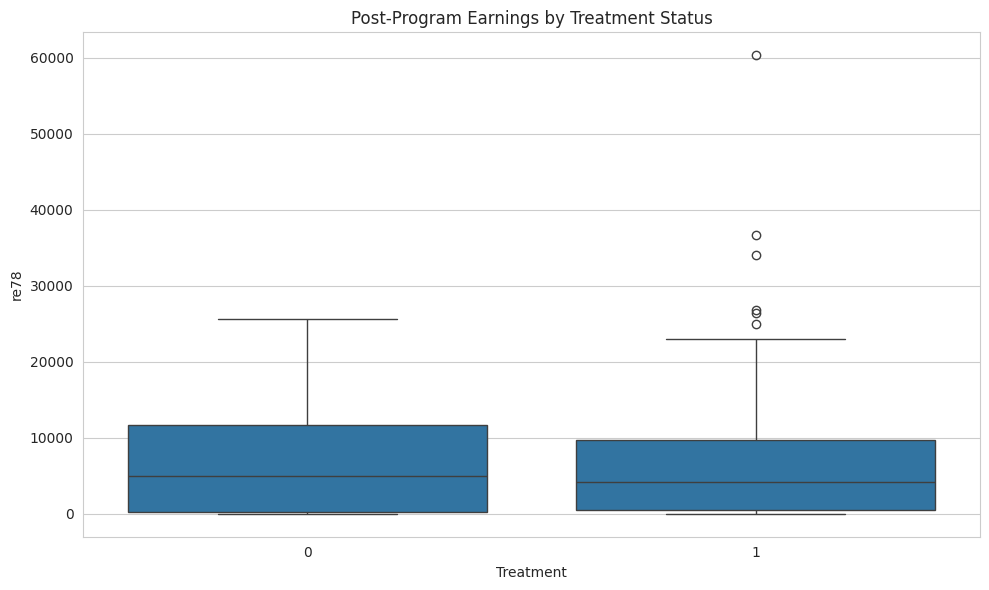

In [26]:
# --- EDA: Treatment-Outcome Visualization ---
# fig, ax = plt.subplots()
# sns.boxplot(data=df, x=treatment_col, y='your_outcome', ax=ax)
# ax.set_title('Outcome by Treatment Status')
# plt.tight_layout()
# plt.show()
fig, ax = plt.subplots()
sns.boxplot(data=df, x='treat', y='re78', ax=ax)
ax.set_title('Post-Program Earnings by Treatment Status')
ax.set_xlabel('Treatment')
ax.set_ylabel('re78')
plt.tight_layout()
plt.show()

---
## Part 3: Analysis

### 3a. Naive Estimate (Biased Benchmark)

This simple comparison is expected to be biased. Document *why*.

In [27]:
# --- Naive OLS ---
# X_naive = df[['your_treatment']]
# X_naive = sm.add_constant(X_naive)
# y = df['your_outcome']
# naive_model = sm.OLS(y, X_naive).fit()
# print(naive_model.summary())
# naive_estimate = naive_model.params['your_treatment']
# naive_ci = naive_model.conf_int().loc['your_treatment'].values
# print(f'\nNaive estimate: {naive_estimate:.4f} (95% CI: [{naive_ci[0]:.4f}, {naive_ci[1]:.4f}])')
X_naive = df[['treat']]
X_naive = sm.add_constant(X_naive)
y = df['re78']

naive_model = sm.OLS(y, X_naive).fit()
print(naive_model.summary())

naive_estimate = naive_model.params['treat']
naive_ci = naive_model.conf_int().loc['treat'].values

print(f"\nNaive estimate: {naive_estimate:.4f} (95% CI: [{naive_ci[0]:.4f}, {naive_ci[1]:.4f}])")

                            OLS Regression Results                            
Dep. Variable:                   re78   R-squared:                       0.002
Model:                            OLS   Adj. R-squared:                 -0.000
Method:                 Least Squares   F-statistic:                    0.9338
Date:                Sun, 26 Apr 2026   Prob (F-statistic):              0.334
Time:                        18:40:57   Log-Likelihood:                -6346.4
No. Observations:                 614   AIC:                         1.270e+04
Df Residuals:                     612   BIC:                         1.271e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       6984.1697    360.710     19.362      0.0

**Why the naive estimate is biased:** The naive estimate may be biased because treated and untreated individuals can differ systematically in pre-treatment characteristics such as education, prior earnings, degree status, and demographic background. As a result, a simple comparison of post-program earnings may reflect selection differences between groups rather than the causal effect of job training itself.

### 3b. Causal Estimate

In [28]:
# --- Causal Method: Double Machine Learning (example) ---
# from econml.dml import LinearDML
#
# Y = df['your_outcome'].values
# T = df['your_treatment'].values
# X = df[['control_1', 'control_2', 'control_3']].values  # effect modifiers (optional)
# W = df[['confounder_1', 'confounder_2']].values          # confounders
#
# dml = LinearDML(
#     model_y=GradientBoostingRegressor(n_estimators=200, random_state=RANDOM_STATE),
#     model_t=GradientBoostingRegressor(n_estimators=200, random_state=RANDOM_STATE),
#     cv=5,
#     random_state=RANDOM_STATE
# )
# dml.fit(Y, T, X=X, W=W)
#
# causal_estimate = dml.ate(X)
# causal_ci = dml.ate_interval(X, alpha=0.05)
# print(f'Causal ATE: {causal_estimate:.4f}')
# print(f'95% CI: [{causal_ci[0]:.4f}, {causal_ci[1]:.4f}]')
# --- Causal Estimate: OLS with Controls ---
X_causal = df[['treat', 'age', 'educ', 'black', 'hispan', 'married', 'nodegree', 're74', 're75']]
X_causal = sm.add_constant(X_causal)
y = df['re78']

causal_model = sm.OLS(y, X_causal).fit()
print(causal_model.summary())

causal_estimate = causal_model.params['treat']
causal_ci = causal_model.conf_int().loc['treat'].values

print(f"\nControlled estimate: {causal_estimate:.4f} (95% CI: [{causal_ci[0]:.4f}, {causal_ci[1]:.4f}])")

                            OLS Regression Results                            
Dep. Variable:                   re78   R-squared:                       0.148
Model:                            OLS   Adj. R-squared:                  0.135
Method:                 Least Squares   F-statistic:                     11.64
Date:                Sun, 26 Apr 2026   Prob (F-statistic):           5.99e-17
Time:                        18:40:57   Log-Likelihood:                -6297.8
No. Observations:                 614   AIC:                         1.262e+04
Df Residuals:                     604   BIC:                         1.266e+04
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         66.5145   2436.746      0.027      0.9

### 3c. Prediction Model (for comparison)

In [29]:
# --- Predictive Model (NOT causal — for comparison only) ---
# from sklearn.metrics import r2_score, mean_squared_error
#
# all_features = ['your_treatment', 'control_1', 'control_2', 'confounder_1']
# rf = RandomForestRegressor(n_estimators=200, random_state=RANDOM_STATE)
# y_pred = cross_val_predict(rf, df[all_features], df['your_outcome'], cv=5)
#
# print(f'Prediction R²: {r2_score(df["your_outcome"], y_pred):.3f}')
# print(f'Prediction RMSE: {np.sqrt(mean_squared_error(df["your_outcome"], y_pred)):.3f}')
# print('\nNote: This tells us how well we can PREDICT the outcome,')
# print('but NOT how the treatment CAUSES changes in the outcome.')
# --- Predictive Model (NOT causal — for comparison only) ---
from sklearn.metrics import r2_score, mean_squared_error

all_features = ['treat', 'age', 'educ', 'black', 'hispan', 'married', 'nodegree', 're74', 're75']

rf = RandomForestRegressor(n_estimators=200, random_state=RANDOM_STATE)
y_pred = cross_val_predict(rf, df[all_features], df['re78'], cv=5)

print(f"Prediction R²: {r2_score(df['re78'], y_pred):.3f}")
print(f"Prediction RMSE: {np.sqrt(mean_squared_error(df['re78'], y_pred)):.3f}")

print("\nNote: This tells us how well we can PREDICT post-program earnings,")
print("but NOT whether job training CAUSES earnings to increase.")

Prediction R²: 0.042
Prediction RMSE: 7306.271

Note: This tells us how well we can PREDICT post-program earnings,
but NOT whether job training CAUSES earnings to increase.


### 3d. Compare Naive vs. Causal

> The naive estimate is [X], the causal estimate is [Y]. The difference of [Z] is attributable to [confounding/selection bias].

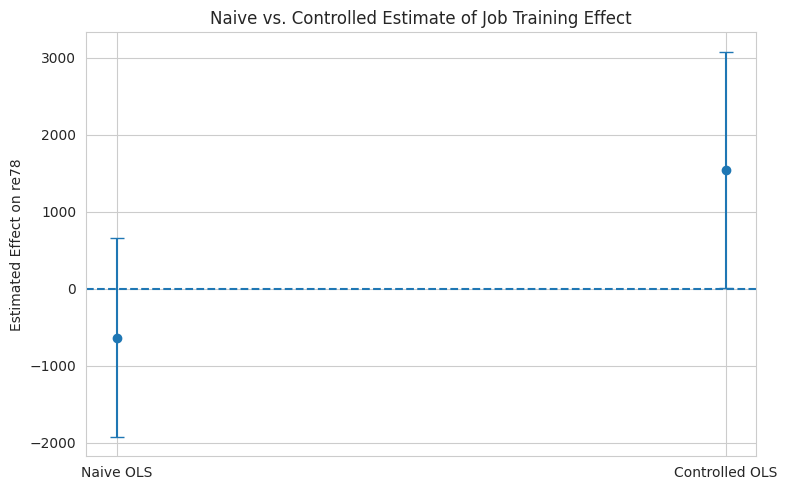

In [30]:
# --- Comparison Plot ---
# fig, ax = plt.subplots(figsize=(8, 5))
#
# estimates = ['Naive OLS', 'Causal (DML)']
# points = [naive_estimate, causal_estimate]
# ci_lower = [naive_ci[0], causal_ci[0]]
# ci_upper = [naive_ci[1], causal_ci[1]]
# errors = [[p - l for p, l in zip(points, ci_lower)],
#           [u - p for p, u in zip(points, ci_upper)]]
#
# ax.errorbar(estimates, points, yerr=errors, fmt='o', capsize=8,
#             markersize=10, linewidth=2, color='#1a237e')
# ax.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
# ax.set_ylabel('Estimated Effect')
# ax.set_title('Naive vs. Causal Estimate')
# plt.tight_layout()
# plt.show()
# --- Comparison Plot ---
fig, ax = plt.subplots(figsize=(8, 5))

estimates = ['Naive OLS', 'Controlled OLS']
points = [naive_estimate, causal_estimate]
ci_lower = [naive_ci[0], causal_ci[0]]
ci_upper = [naive_ci[1], causal_ci[1]]

errors = [
    [p - l for p, l in zip(points, ci_lower)],
    [u - p for p, u in zip(points, ci_upper)]
]

ax.errorbar(estimates, points, yerr=errors, fmt='o', capsize=5)
ax.axhline(0, linestyle='--')
ax.set_ylabel('Estimated Effect on re78')
ax.set_title('Naive vs. Controlled Estimate of Job Training Effect')
plt.tight_layout()
plt.show()

### 3e. Robustness Check

In [31]:
# --- Robustness: Different nuisance model ---
# dml_robust = LinearDML(
#     model_y=RandomForestRegressor(n_estimators=200, random_state=RANDOM_STATE),
#     model_t=RandomForestRegressor(n_estimators=200, random_state=RANDOM_STATE),
#     cv=5,
#     random_state=RANDOM_STATE
# )
# dml_robust.fit(Y, T, X=X, W=W)
# robust_ate = dml_robust.ate(X)
# robust_ci = dml_robust.ate_interval(X, alpha=0.05)
# print(f'Robustness ATE (RF nuisance): {robust_ate:.4f}')
# print(f'95% CI: [{robust_ci[0]:.4f}, {robust_ci[1]:.4f}]')
# --- Robustness Check: Alternative Specification ---
X_robust = df[['treat', 'age', 'educ', 'black', 'hispan', 'married', 'nodegree']]
X_robust = sm.add_constant(X_robust)
y = df['re78']

robust_model = sm.OLS(y, X_robust).fit()
print(robust_model.summary())

robust_estimate = robust_model.params['treat']
robust_ci = robust_model.conf_int().loc['treat'].values

print(f"\nRobustness estimate: {robust_estimate:.4f} (95% CI: [{robust_ci[0]:.4f}, {robust_ci[1]:.4f}])")

                            OLS Regression Results                            
Dep. Variable:                   re78   R-squared:                       0.071
Model:                            OLS   Adj. R-squared:                  0.060
Method:                 Least Squares   F-statistic:                     6.594
Date:                Sun, 26 Apr 2026   Prob (F-statistic):           1.59e-07
Time:                        18:41:01   Log-Likelihood:                -6324.3
No. Observations:                 614   AIC:                         1.266e+04
Df Residuals:                     606   BIC:                         1.270e+04
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       -814.6786   2527.166     -0.322      0.7

## Part 4: Threats to Identification

This project estimates the effect of participation in a job training program on post-program earnings (`re78`). Although the controlled regression produces a positive and statistically significant estimate, there are still important threats to identification that limit how confidently I can interpret the result as fully causal. The main concern is that treated and untreated individuals may differ in ways that are not fully captured by the observed control variables. My analysis includes age, education, race/ethnicity, marital status, degree status, and prior earnings (`re74`, `re75`), but those controls may still be incomplete.

### 1. Most Serious Threat

- **Threat:** Omitted variable bias / selection on unobservables.  
  Even after controlling for observed characteristics, treated individuals may differ from untreated individuals in motivation, job search effort, health, informal work experience, local labor market opportunities, or willingness to participate in training. These factors may affect both treatment participation and later earnings.

- **Direction of bias:**  
  The direction of bias is ambiguous, but in this project the naive estimate is negative while the controlled estimate becomes positive. That pattern suggests the simple comparison may understate the treatment effect. One possible interpretation is that treated individuals were more disadvantaged before treatment, so failing to control for pre-treatment differences biases the estimated effect downward. However, I cannot rule out the opposite possibility that some unobserved characteristics positively select people into treatment, which would make my controlled estimate too large.

- **What would address it:**  
  The strongest solution would be a clearly randomized assignment mechanism with full documentation, or richer pre-treatment data that capture labor market readiness, baseline ability, and local economic conditions. A stronger research design such as a verified randomized controlled trial, a valid instrument, or a natural experiment would also improve identification.

### 2. Second Threat

- **Threat:** Model dependence / sensitivity to specification.  
  My estimated treatment effect changes depending on which controls are included. In particular, the estimate remains positive in the robustness check, but it becomes less precise when pre-program earnings controls are removed.

- **Why it matters:**  
  This means the result depends importantly on controlling for prior earnings. If the model specification is incomplete or misspecified, the estimated effect of treatment may change in magnitude and significance. That weakens confidence that the result is fully stable.

- **Partial mitigation:**  
  I partially address this by comparing a naive model, a controlled model, and a robustness specification. The treatment effect stays positive once reasonable controls are used, which is reassuring. However, because the precision changes across specifications, I should interpret the result cautiously.

### 3. What I Cannot Rule Out

I cannot fully rule out remaining unobserved differences between treated and untreated individuals. Even though the controlled estimate is positive and statistically significant, it may still reflect some combination of treatment effects and residual selection bias. Therefore, my estimate should be interpreted as **evidence consistent with a positive causal effect**, rather than as a definitive causal effect under all possible assumptions.

Overall, the most credible conclusion is that job training appears to increase earnings after adjusting for observed pre-treatment differences, but this conclusion still depends on the assumption that the available controls adequately account for selection into treatment. This limitation is important and should remain central when interpreting the final results.

---
## Part 5: Streamlit Dashboard Export

Copy the template below into a file called `app.py` in your project repo. Customize the what-if logic with your actual model.

**Deploy to Streamlit Community Cloud** and submit the permanent URL.

In [33]:
# Save this as app.py in your project repo

streamlit_template = '''
import streamlit as st
import pandas as pd
import numpy as np
import plotly.graph_objects as go

st.set_page_config(page_title="Consulting Report Dashboard", layout="wide")
st.title("Consulting Report: [Your Title]")

# --- Sidebar: What-If Controls ---
st.sidebar.header("What-If Scenarios")

treatment_multiplier = st.sidebar.slider(
    "Treatment intensity multiplier",
    min_value=0.5, max_value=3.0, value=1.0, step=0.1
)

# TODO: Add more sliders for your specific parameters
# control_level = st.sidebar.selectbox("Control scenario", ["Low", "Medium", "High"])

# --- Load your fitted model or pre-computed results ---
# Option 1: Load a pickled model
# import joblib
# model = joblib.load("fitted_model.pkl")

# Option 2: Use pre-computed coefficients
baseline_ate = 1548.2438
baseline_se = 781.279

# --- Compute What-If Estimate ---
adjusted_ate = baseline_ate * treatment_multiplier
adjusted_se = baseline_se * treatment_multiplier
ci_lower = adjusted_ate - 1.96 * adjusted_se
ci_upper = adjusted_ate + 1.96 * adjusted_se

# --- Display Results ---
col1, col2, col3 = st.columns(3)
col1.metric("Estimated Effect", f"{adjusted_ate:.3f}")
col2.metric("95% CI Lower", f"{ci_lower:.3f}")
col3.metric("95% CI Upper", f"{ci_upper:.3f}")

st.markdown(f"""
> **What-if interpretation:** If treatment intensity is multiplied by
> {treatment_multiplier:.1f}x, the estimated effect changes to
> {adjusted_ate:.3f} (95% CI: [{ci_lower:.3f}, {ci_upper:.3f}]).
""")

# --- Uncertainty Visualization ---
multipliers = np.arange(0.5, 3.1, 0.1)
ates = baseline_ate * multipliers
ses = baseline_se * multipliers

fig = go.Figure()
fig.add_trace(go.Scatter(
    x=multipliers, y=ates + 1.96 * ses,
    mode="lines", line=dict(width=0), showlegend=False
))
fig.add_trace(go.Scatter(
    x=multipliers, y=ates - 1.96 * ses,
    mode="lines", line=dict(width=0), fill="tonexty",
    fillcolor="rgba(26,35,126,0.2)", name="95% CI"
))
fig.add_trace(go.Scatter(
    x=multipliers, y=ates,
    mode="lines", line=dict(color="#1a237e", width=2), name="Estimated Effect"
))
fig.add_vline(x=treatment_multiplier, line_dash="dash", line_color="red",
              annotation_text=f"Current: {treatment_multiplier:.1f}x")
fig.update_layout(
    title="What-If: Effect vs. Treatment Intensity",
    xaxis_title="Treatment Intensity Multiplier",
    yaxis_title="Estimated Causal Effect",
    template="plotly_white"
)
st.plotly_chart(fig, use_container_width=True)

# --- Counterfactual Scenario ---
st.subheader("Counterfactual: What if treatment intensity doubled?")
counterfactual_ate = baseline_ate * 2.0
counterfactual_ci = (counterfactual_ate - 1.96 * baseline_se * 2.0,
                     counterfactual_ate + 1.96 * baseline_se * 2.0)
st.write(f"If treatment intensity doubled, the estimated effect would be "
         f"**{counterfactual_ate:.3f}** (95% CI: [{counterfactual_ci[0]:.3f}, {counterfactual_ci[1]:.3f}]).")
'''

# Uncomment to write the template to disk:
# with open('app.py', 'w') as f:
#     f.write(streamlit_template)
# print('app.py written. Deploy to Streamlit Community Cloud.')

print('Streamlit template ready. Uncomment the write block above to export.')

Streamlit template ready. Uncomment the write block above to export.


In [34]:
with open('app.py', 'w') as f:
    f.write(streamlit_template)
print('app.py written. Deploy to Streamlit Community Cloud.')

app.py written. Deploy to Streamlit Community Cloud.


---
## Part 6: Presentation Script

**5 minutes total. Practice with a timer.**

| Segment | Time | Your Script |
|---------|------|-------------|
| **Hook** | 30s | ___ |
| **Problem** | 60s | ___ |
| **Method** | 60s | ___ |
| **Finding** | 60s | ___ |
| **Recommendation** | 60s | ___ |
| **Defense** | 30s | ___ |

### Adversarial Prep

| Question Category | Your Prepared Answer |
|-------------------|---------------------|
| "How do you know this is causal?" | ___ |
| "Why this model?" | ___ |
| "Would this generalize?" | ___ |
| "Is the effect large enough?" | ___ |

---
## Part 7: AI Methodology Appendix (P.R.I.M.E.)

Document at least 3 significant AI interactions.

### Entry 1: [Task — e.g., Code Generation]

- **Prompt:** [What you asked the AI]
- **Response:** [Summary of what the AI produced]
- **Iterate:** [What you changed or asked to refine]
- **Modify:** [How you adapted the output for your specific use case]
- **Evaluate:** [How you verified correctness — tests run, sources checked, logic reviewed]

### Entry 2: [Task — e.g., Analysis Assistance]

- **Prompt:** ___
- **Response:** ___
- **Iterate:** ___
- **Modify:** ___
- **Evaluate:** ___

### Entry 3: [Task — e.g., Writing / Literature Review]

- **Prompt:** ___
- **Response:** ___
- **Iterate:** ___
- **Modify:** ___
- **Evaluate:** ___